In [ ]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

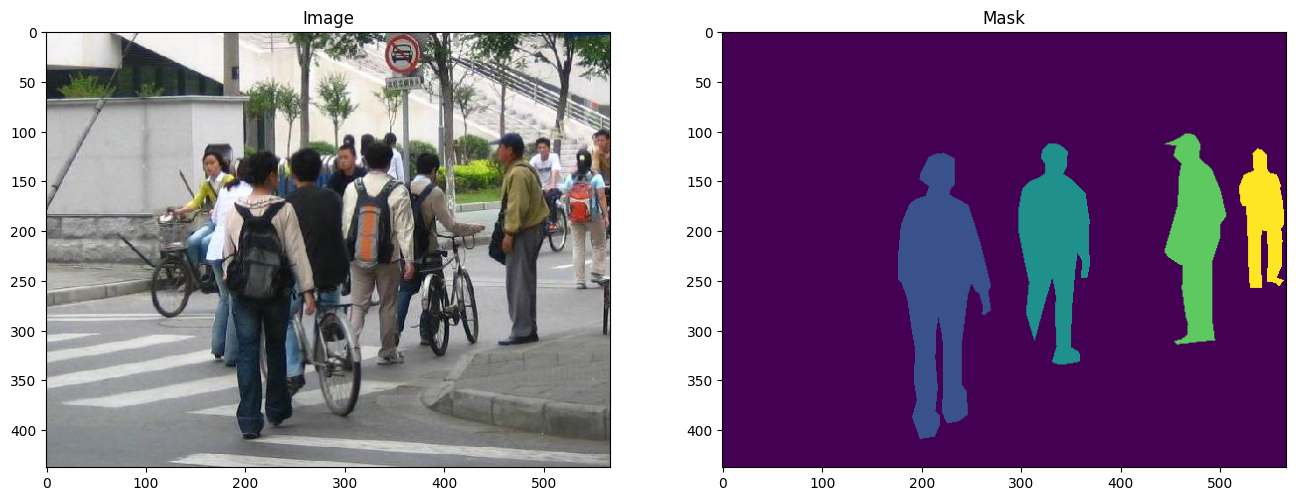

In [2]:
import matplotlib.pyplot as plt
from torchvision.io import read_image


image = read_image("data/PennFudanPed/PNGImages/FudanPed00046.png")
mask = read_image("data/PennFudanPed/PedMasks/FudanPed00046_mask.png")

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title("Image")
plt.imshow(image.permute(1, 2, 0))
plt.subplot(122)
plt.title("Mask")
plt.imshow(mask.permute(1, 2, 0))

In [3]:
import os
import torch

from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F


class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # load all image files, sorting them to
        # ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        # load images and masks
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        img = read_image(img_path)
        mask = read_image(mask_path)
        # instances are encoded as different colors
        obj_ids = torch.unique(mask)
        # first id is the background, so remove it
        obj_ids = obj_ids[1:]
        num_objs = len(obj_ids)

        # split the color-encoded mask into a set
        # of binary masks
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)

        # get bounding box coordinates for each mask
        boxes = masks_to_boxes(masks)

        # there is only one class
        labels = torch.ones((num_objs,), dtype=torch.int64)

        image_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # suppose all instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Wrap sample and targets into torchvision tv_tensors:
        img = tv_tensors.Image(img)

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
        target["masks"] = tv_tensors.Mask(masks)
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

In [4]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator


In [5]:
def get_model_instance_segmentation(num_classes):       # option 1
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model  


def get_model_mobilenet_fasterrcnn(num_classes):        # option 2
    backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features
    backbone.out_channels = 1280

    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )

    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )

    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )

    return model   

In [6]:
num_classes = 2

model_opt1 = get_model_instance_segmentation(num_classes)
model_opt2 = get_model_mobilenet_fasterrcnn(num_classes)

In [7]:
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py")

--2025-11-13 05:47:52--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4063 (4.0K) [text/plain]
Saving to: ‘engine.py.5’

     0K ...                                                   100% 45.6M=0s

2025-11-13 05:47:52 (45.6 MB/s) - ‘engine.py.5’ saved [4063/4063]

--2025-11-13 05:47:52--  https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8388 (8.2K) [text/plain]
S

0

In [8]:
from torchvision.transforms import v2 as T


def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

In [9]:
from engine import train_one_epoch, evaluate
import utils

# train on the accelerator or on the CPU, if an accelerator is not available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}") 


# train the model
def train(model):
    # our dataset has two classes only - background and person
    num_classes = 2
    # use our dataset and defined transformations
    dataset = PennFudanDataset('data/PennFudanPed', get_transform(train=True))
    dataset_test = PennFudanDataset('data/PennFudanPed', get_transform(train=False))

    # split the dataset in train and test set
    indices = torch.randperm(len(dataset)).tolist()
    dataset = torch.utils.data.Subset(dataset, indices[:-50])
    dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

    # define training and validation data loaders
    data_loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=2,
        shuffle=True,
        collate_fn=utils.collate_fn
    )

    data_loader_test = torch.utils.data.DataLoader(
        dataset_test,
        batch_size=1,
        shuffle=False,
        collate_fn=utils.collate_fn
    )


    # move model to the right device
    model.to(device)

    # construct an optimizer
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(
        params,
        lr=0.005,
        momentum=0.9,
        weight_decay=0.0005
    )

    # and a learning rate scheduler
    lr_scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=3,
        gamma=0.1
    )

    # let's train it just for 10 epochs
    num_epochs = 10 # 2

    for epoch in range(num_epochs):
        # train for one epoch, printing every 10 iterations
        train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
        # update the learning rate
        lr_scheduler.step()
        # evaluate on the test dataset
        evaluate(model, data_loader_test, device=device)

    print("That's it!")

Using device: cuda


# Option 1

In [10]:
train(model_opt1)

/workspace/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/60]  eta: 0:00:53  lr: 0.000090  loss: 3.2603 (3.2603)  loss_classifier: 0.5706 (0.5706)  loss_box_reg: 0.1501 (0.1501)  loss_mask: 2.5274 (2.5274)  loss_objectness: 0.0105 (0.0105)  loss_rpn_box_reg: 0.0016 (0.0016)  time: 0.8901  data: 0.0114  max mem: 1789
Epoch: [0]  [10/60]  eta: 0:00:10  lr: 0.000936  loss: 1.5854 (1.8521)  loss_classifier: 0.3762 (0.3639)  loss_box_reg: 0.3032 (0.2852)  loss_mask: 0.7910 (1.1756)  loss_objectness: 0.0218 (0.0221)  loss_rpn_box_reg: 0.0035 (0.0053)  time: 0.2198  data: 0.0187  max mem: 2458
Epoch: [0]  [20/60]  eta: 0:00:07  lr: 0.001783  loss: 0.8021 (1.2937)  loss_classifier: 0.2093 (0.2636)  loss_box_reg: 0.2346 (0.2644)  loss_mask: 0.3271 (0.7367)  loss_objectness: 0.0218 (0.0231)  loss_rpn_box_reg: 0.0056 (0.0058)  time: 0.1502  data: 0.0192  max mem: 2592
Epoch: [0]  [30/60]  eta: 0:00:05  lr: 0.002629  loss: 0.6221 (1.0771)  loss_classifier: 0.1082 (0.2115)  loss_box_reg: 0.2180 (0.2675)  loss_mask: 0.2173 (0.5733)  loss_ob

# Option 2

In [11]:
train(model_opt2)

Epoch: [0]  [ 0/60]  eta: 0:00:10  lr: 0.000090  loss: 1.4493 (1.4493)  loss_classifier: 0.6684 (0.6684)  loss_box_reg: 0.0320 (0.0320)  loss_objectness: 0.6869 (0.6869)  loss_rpn_box_reg: 0.0621 (0.0621)  time: 0.1813  data: 0.0197  max mem: 3512
Epoch: [0]  [10/60]  eta: 0:00:06  lr: 0.000936  loss: 1.3852 (1.3772)  loss_classifier: 0.6184 (0.6015)  loss_box_reg: 0.0475 (0.0513)  loss_objectness: 0.6828 (0.6795)  loss_rpn_box_reg: 0.0481 (0.0449)  time: 0.1231  data: 0.0187  max mem: 5498
Epoch: [0]  [20/60]  eta: 0:00:04  lr: 0.001783  loss: 1.1322 (1.2197)  loss_classifier: 0.4151 (0.4584)  loss_box_reg: 0.0658 (0.0809)  loss_objectness: 0.6422 (0.6380)  loss_rpn_box_reg: 0.0422 (0.0423)  time: 0.1181  data: 0.0200  max mem: 5498
Epoch: [0]  [30/60]  eta: 0:00:03  lr: 0.002629  loss: 1.0412 (1.1393)  loss_classifier: 0.2967 (0.4062)  loss_box_reg: 0.1276 (0.1139)  loss_objectness: 0.5330 (0.5759)  loss_rpn_box_reg: 0.0393 (0.0433)  time: 0.1193  data: 0.0214  max mem: 5498
Epoch: [

In [12]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks


# to make it more clear, I added a score thresh to filter out those boxes with meaninglessly low scores.
def valid(model, score_thresh=0.5, img = "data/PennFudanPed/PNGImages/FudanPed00046.png"):
    image = read_image(img)
    eval_transform = get_transform(train=False)

    model.eval()
    with torch.no_grad():
        x = eval_transform(image)
        x = x[:3, ...].to(device)
        predictions = model([x])
        pred = predictions[0]

    image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
    image = image[:3, ...]  

    scores = pred["scores"]
    boxes = pred["boxes"]
    labels = pred["labels"]

    keep = scores >= score_thresh         
    scores = scores[keep]
    boxes = boxes[keep]
    labels = labels[keep]

    if scores.numel() == 0:
        print("No detections above threshold.")
        return

    pred_labels = [f"pedestrian: {s:.3f}" for s in scores]
    pred_boxes = boxes.to(torch.int64)

    output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

    if "masks" in pred:
        masks = pred["masks"][keep]
        masks = (masks > 0.7).squeeze(1)   # [N, 1, H, W] -> [N, H, W]
        output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

    output_image = output_image.cpu()

    plt.figure(figsize=(12, 12))
    plt.imshow(output_image.permute(1, 2, 0))
    plt.axis("off")


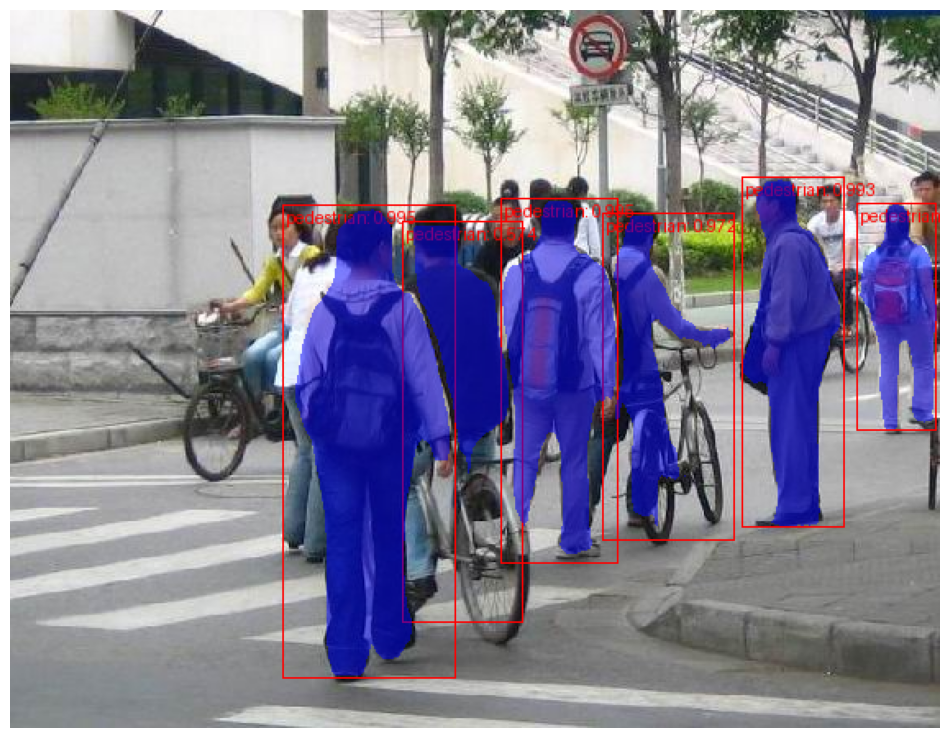

In [13]:
valid(model_opt1)

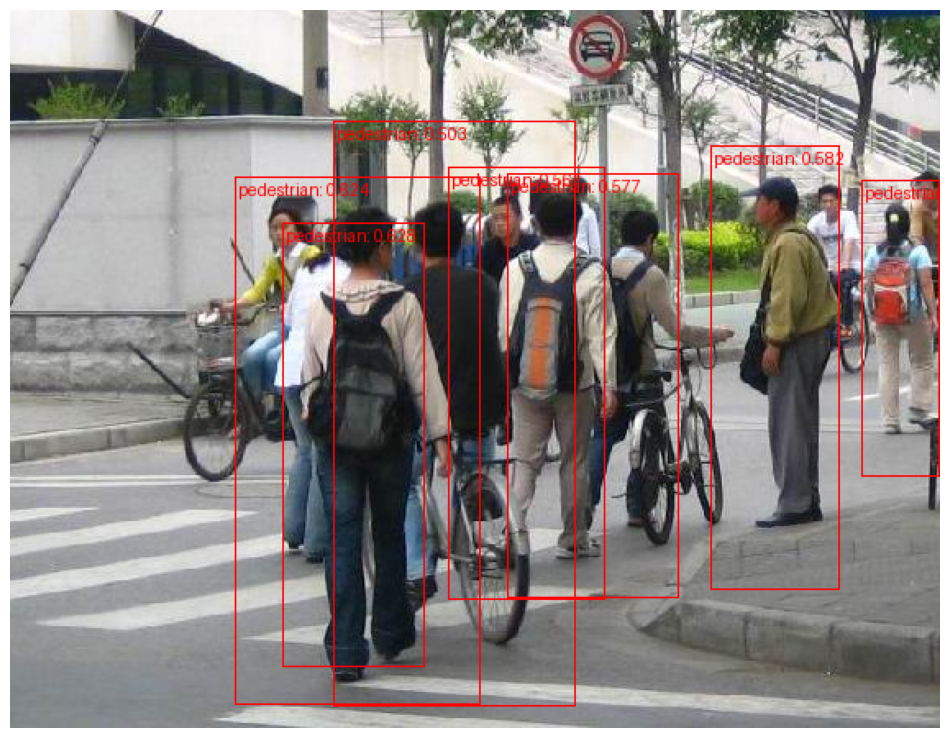

In [14]:
valid(model_opt2)

# Beatles Tests

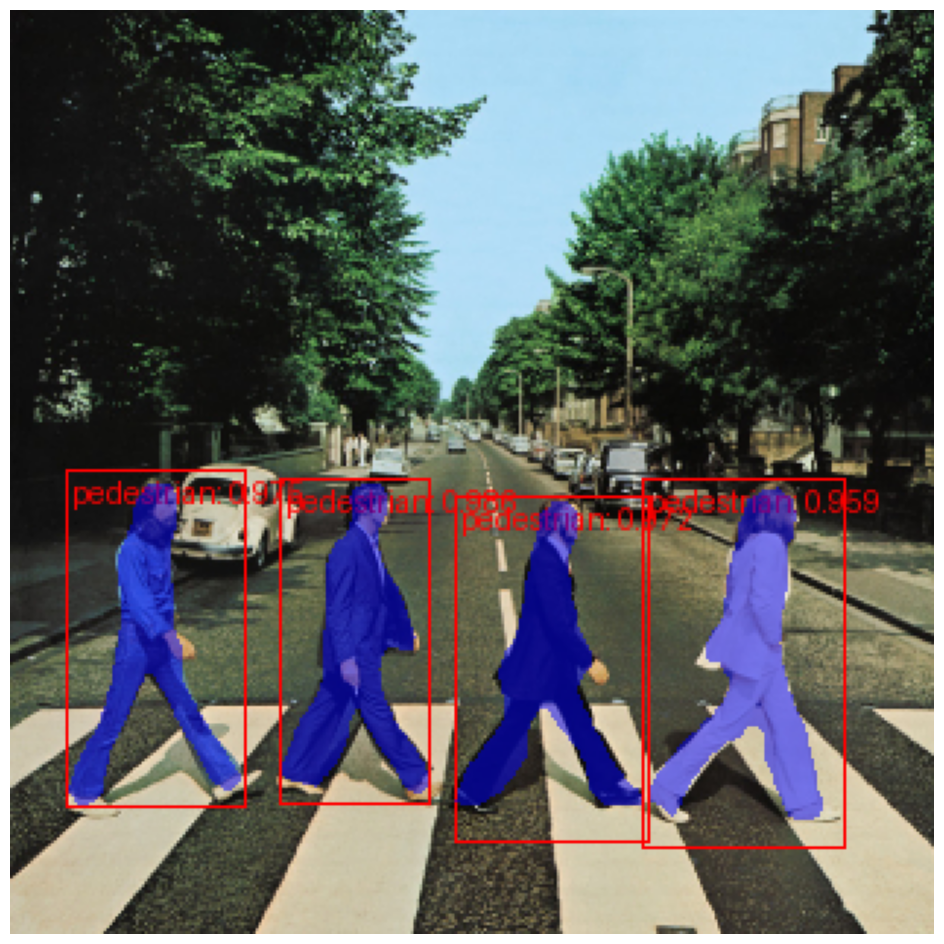

In [15]:
# OPT 1
valid(model_opt1, img = 'beatles.jpg')

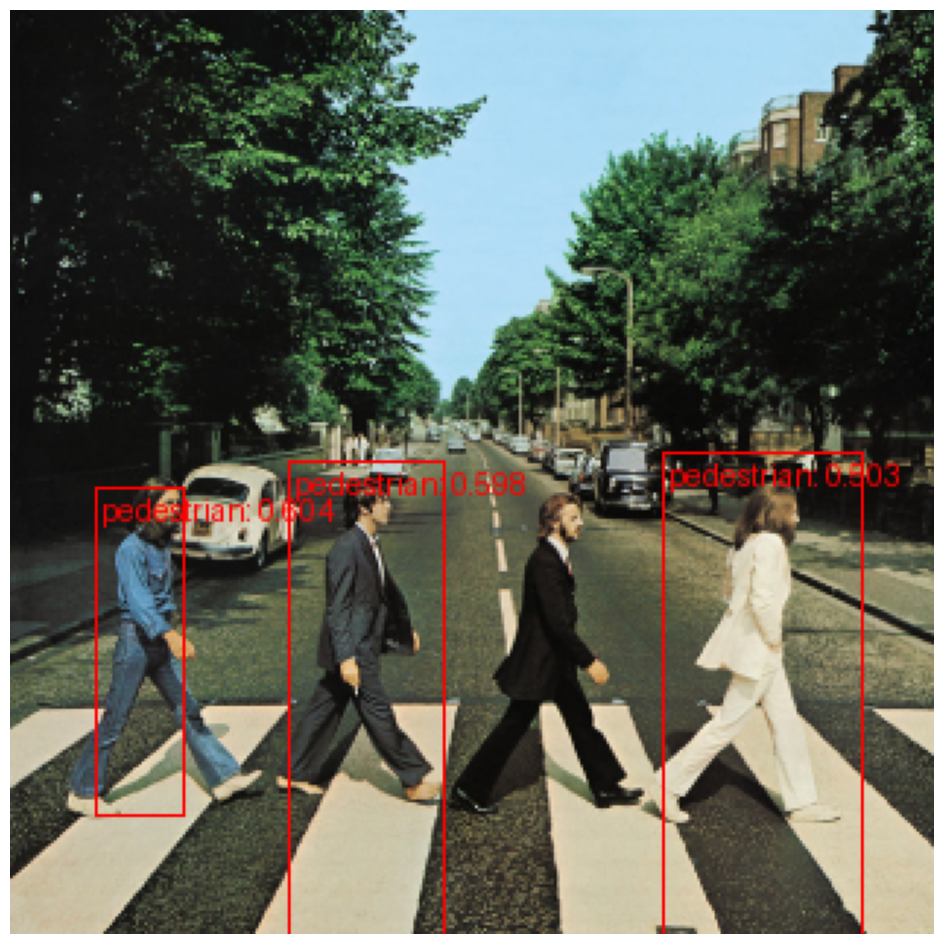

In [16]:
# OPT 2
valid(model_opt2, img = 'beatles.jpg')